In [1]:
!pip install efficientnet

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import numpy as np
import pandas as pd
import cv2
import os
import shutil
from tqdm import tqdm
import random
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
import keras
from keras import preprocessing
from keras import layers
from keras import models, Model
from tqdm import tqdm
from keras import regularizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam, SGD, RMSprop, Adamax
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import ResNet50, EfficientNetB3, DenseNet121, EfficientNetB0, EfficientNetB1
from tensorflow.keras.layers import Input
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D, Input, Activation
from keras.models import Sequential

%matplotlib inline
sns.set_style('darkgrid')
warnings.filterwarnings('ignore')

In [24]:
training_df = pd.read_csv('C:/Users/harma/OneDrive/Desktop/project2/data2/balanced_labels_pv.csv')
train_df = pd.read_csv('C:/Users/harma/OneDrive/Desktop/project2/data2/new_balanced_labels.csv')
test_df = pd.read_csv('C:/Users/harma/OneDrive/Desktop/project2/data2/test.csv')
print(train_df.shape)
print(test_df.shape)
print(training_df.shape)

(6008, 2)
(1928, 1)
(6008, 2)


In [25]:
train_df.diagnosis.value_counts()

diagnosis
2    2700
1     920
4     845
0     800
3     743
Name: count, dtype: int64

In [26]:
training_df.diagnosis.value_counts()

diagnosis
2    2700
1     920
4     845
0     800
3     743
Name: count, dtype: int64

In [27]:
print('Displaying Image Codes and their Labels(Train)')
# train_df['id_code'] = train_df['id_code'] + '.png'
display(train_df.head())
print('Displaying Image Codes(Test)')
test_df['id_code'] = test_df['id_code'] + '.png'
display(test_df.head())

Displaying Image Codes and their Labels(Train)


,id_code,diagnosis
0,ef5155990874.png,0
1,0a85a1e8f9e9.png,0
2,6a2642131e4a.png,0
3,8a8a251770cd.png,0
4,ac1667fac512.png,0


Displaying Image Codes(Test)


,id_code
0,0005cfc8afb6.png
1,003f0afdcd15.png
2,006efc72b638.png
3,00836aaacf06.png
4,009245722fa4.png


In [28]:
train_images_dir = 'C:/Users/harma/OneDrive/Desktop/project2/data2/train_images'
test_images_dir = 'C:/Users/harma/OneDrive/Desktop/project2/data2/test_images'
preprocessed_train_images_dir = 'C:/Users/harma/OneDrive/Desktop/project2/data2/preprocessed_images'

error: OpenCV(4.12.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


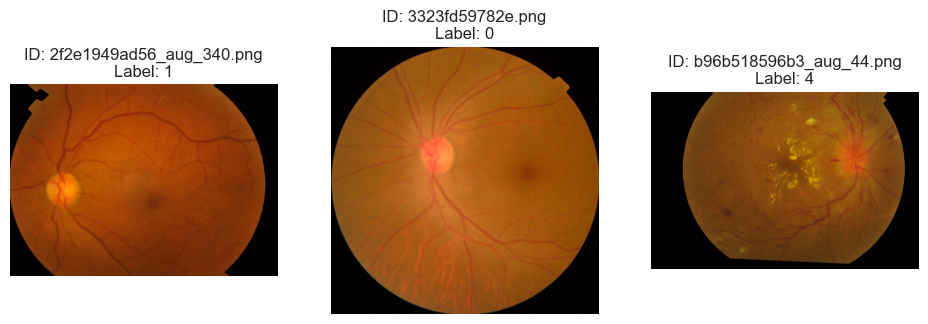

In [29]:
def display_images_with_labels(dataframe, image_dir, num_images=10):
    sample_df = dataframe.sample(n=num_images)

    plt.figure(figsize=(20, 8))

    for i, row in enumerate(sample_df.iterrows()):
        idx, row_data = row
        img_path = os.path.join(image_dir, row_data['id_code'])
        label = row_data['diagnosis']

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(2, 5, i + 1)
        plt.imshow(img)
        plt.title(f"ID: {row_data['id_code']}\nLabel: {label}")
        plt.axis('off')

    plt.show()

display_images_with_labels(training_df, train_images_dir, num_images=10)

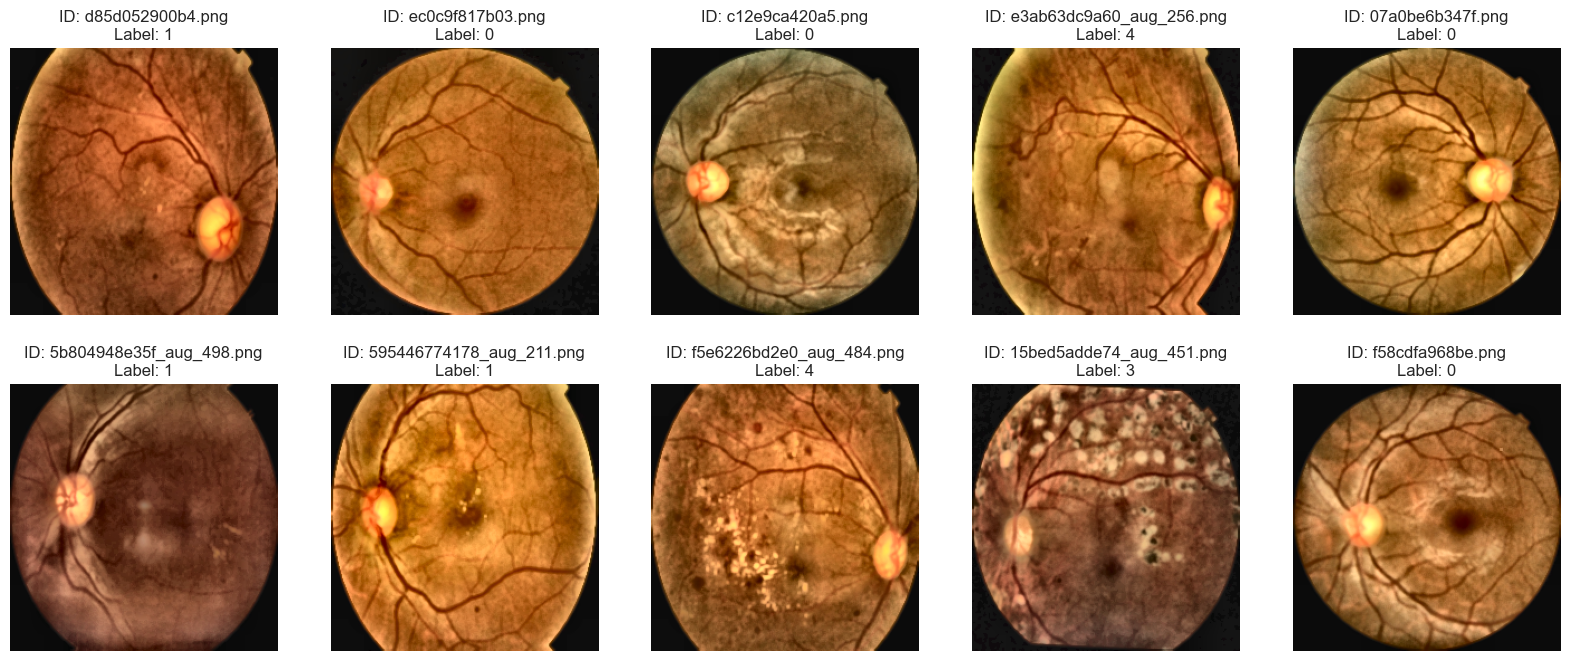

In [ ]:
def display_images_with_labels(dataframe, image_dir, num_images=10):
    sample_df = dataframe.sample(n=num_images)

    plt.figure(figsize=(20, 8))

    for i, row in enumerate(sample_df.iterrows()):
        idx, row_data = row
        img_path = os.path.join(image_dir, row_data['id_code'])
        label = row_data['diagnosis']

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(2, 5, i + 1)
        plt.imshow(img)
        plt.title(f"ID: {row_data['id_code']}\nLabel: {label}")
        plt.axis('off')

    plt.show()

display_images_with_labels(train_df, preprocessed_train_images_dir, num_images=10)

In [ ]:
# Paths
csv_path = "C:/Users/harma/OneDrive/Desktop/project2/data2/new_balanced_labels.csv"
image_folder = "C:/Users/harma/OneDrive/Desktop/project2/data2/preprocessed_images"

# Load CSV
df = pd.read_csv(csv_path)

# Define fixed classes
fixed_classes = [0,3,4,1]  # Constant classes
other_classes = [2]  # Classes to pair with (0,3)

# Create ternary class groups
multiclass_groups = [(fixed_classes, [cls]) for cls in other_classes]

# Display ternary class groups
print("Generated Quaternary Class Groups:", multiclass_groups)

Generated Quaternary Class Groups: [([0, 3, 4, 1], [2])]


In [ ]:
def load_data_for_multiclass_classification(fixed_classes, other_class):
    """Loads images and labels for a ternary classification task."""

    # Select only the required classes
    multiclass_df = df[df['diagnosis'].isin(fixed_classes + [other_class])]
    print(f"\n🔍 Checking dataset for {fixed_classes} vs. {other_class} | Total samples: {len(multiclass_df)}")
    print(multiclass_df['diagnosis'].value_counts())

    images, labels = [], []
    for _, row in tqdm(multiclass_df.iterrows(), total=len(multiclass_df)):
        img_id = row['id_code']
        img_path = os.path.join(image_folder, img_id)

        if os.path.exists(img_path):
            image = cv2.imread(img_path)  # Read in BGR format
            if image is None:
                print(f"⚠️ OpenCV could not read: {img_path}")
                continue  # Skip unreadable images

            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB
            image = cv2.resize(image, (240, 240))  # Resize to 240x240
            images.append(image)

            # Assign labels: (0,3) → 0, other_class → 1
            labels.append(0 if row['diagnosis'] in fixed_classes else 1)

    if not images:
        raise ValueError("❌ No images found. Check file paths or preprocessing.")

    images = np.array(images)
    labels = np.array(labels)

    print(f"✅ Loaded {len(images)} images successfully.")
    return images, labels

print("Image loading function for multiclass classification defined successfully.")

Image loading function for multiclass classification defined successfully.


In [ ]:
print(f"📂 image_folder: {image_folder} | Type: {type(image_folder)}")

📂 image_folder: C:/Users/harma/OneDrive/Desktop/project2/data2/preprocessed_images | Type: <class 'str'>


In [ ]:
def get_data_generators_for_multiclass(fixed_classes, other_class, batch_size=32):
    """Creates data generators for quaternary classification with augmentation."""

    # Load images and labels
    X, y = load_data_for_multiclass_classification(fixed_classes, other_class)

    # Create a DataFrame for image paths and labels
    multiclass_df = pd.DataFrame({"id_code": df[df['diagnosis'].isin(fixed_classes + [other_class])]['id_code'], "label": y})

    # Train-validation split (80-20 split)
    train_df, val_df = train_test_split(multiclass_df, test_size=0.2, random_state=42, stratify=multiclass_df["label"])

    # Convert labels to string format (Fix for categorical generator)
    train_df["label"] = train_df["label"].astype(str)
    val_df["label"] = val_df["label"].astype(str)

    # ImageDataGenerator for data augmentation (Training)
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        zoom_range=0.15,
        horizontal_flip=True,
        brightness_range=(0.7, 1.3),
        fill_mode='nearest'
    )

    # Validation generator (No augmentation)
    val_datagen = ImageDataGenerator(rescale=1./255)

    # Create train generator
    train_generator = train_datagen.flow_from_dataframe(
        dataframe=train_df, directory=image_folder, x_col="id_code", y_col="label", class_mode="binary", target_size=(240, 240), batch_size=batch_size, shuffle= False)

    # Create validation generator
    val_generator = val_datagen.flow_from_dataframe(
        dataframe=val_df, directory=image_folder, x_col="id_code", y_col="label", class_mode="binary", target_size=(240, 240), batch_size=batch_size, shuffle=False
    )

    return train_generator, val_generator

print("Multiclass classification data generator function defined successfully.")

Multiclass classification data generator function defined successfully.


In [ ]:
train_generator, val_generator = get_data_generators_for_multiclass([0, 3, 4, 1], 2)


🔍 Checking dataset for [0, 3, 4, 1] vs. 2 | Total samples: 4118
diagnosis
1    920
4    845
2    810
0    800
3    743
Name: count, dtype: int64


100%|██████████| 4118/4118 [00:11<00:00, 360.43it/s]


✅ Loaded 4118 images successfully.
Found 3294 validated image filenames belonging to 2 classes.
Found 824 validated image filenames belonging to 2 classes.


In [ ]:
X_train_batch, y_train_batch = next(train_generator)
print("Train batch shape:", X_train_batch.shape, y_train_batch.shape)

X_val_batch, y_val_batch = next(val_generator)
print("Validation batch shape:", X_val_batch.shape, y_val_batch.shape)

Train batch shape: (32, 240, 240, 3) (32,)
Validation batch shape: (32, 240, 240, 3) (32,)


In [ ]:
print(train_generator.samples)  # Should print a nonzero number
print(val_generator.samples)  # Should print a nonzero number

3294
824


In [ ]:
import numpy as np
unique, counts = np.unique(val_generator.labels, return_counts=True)
print(unique, counts)

[0 1] [662 162]


In [ ]:
# Load the CSV file containing original labels
df_original = pd.read_csv("C:/Users/harma/OneDrive/Desktop/project2/data2/new_balanced_labels.csv")  # Ensure correct path

# Load the train generator filenames
train_filenames = train_generator.filenames  # Get image filenames from train generator

# Extract image ID codes from filenames (Remove .png extension)
train_id_codes = [filename.split("/")[-1] for filename in train_filenames]

# Create a DataFrame for train generator samples
df_train = pd.DataFrame({"id_code": train_id_codes})

# Merge with the original labels DataFrame to get the original diagnosis
df_train = df_train.merge(df_original, on="id_code", how="left")  # Ensure correct merge

# Save to Excel
excel_filename = f"C:/Users/harma/OneDrive/Desktop/project2/data2/traingenerator_dataset_info.xlsx"
df_train.to_excel(excel_filename, index=False)

print("✅ Train generator data saved with original labels!")

✅ Train generator data saved with original labels!


In [ ]:
# Load the CSV file containing original labels
df_original = pd.read_csv("C:/Users/harma/OneDrive/Desktop/project2/data2/new_balanced_labels.csv")  # Ensure correct path

# Load the val generator filenames
val_filenames = val_generator.filenames  # Get image filenames from train generator

# Extract image ID codes from filenames (Remove .png extension)
val_id_codes = [filename.split("/")[-1] for filename in val_filenames]

# Create a DataFrame for val generator samples
df_val = pd.DataFrame({"id_code": val_id_codes})

# Merge with the original labels DataFrame to get the original diagnosis
df_val = df_val.merge(df_original, on="id_code", how="left")  # Ensure correct merge

# Save to Excel
excel_filename = f"C:/Users/harma/OneDrive/Desktop/project2/data2/valgenerator_dataset_info.xlsx"
df_val.to_excel(excel_filename, index=False)

print("✅ Val generator data saved with original labels!")

✅ Val generator data saved with original labels!


In [ ]:
def create_model():
    """Creates and compiles the EfficientNet model."""

    input_shape = (240, 240, 3)
    inputs = Input(shape=input_shape, name='input_1')

    # Load the Efficientnetb1 base model
    base_model = EfficientNetB1(weights= 'imagenet', include_top=False, input_shape = input_shape)

    # Freeze the base model layers
    # for layer in base_model.layers:
    #   layer.trainable = False

    # Freeze only the first 100 layers instead of all layers
    for layer in base_model.layers[:100]:
        layer.trainable = False
    for layer in base_model.layers[100:]:
        layer.trainable = True

    # Add custom layers on top of the base model
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(256, kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    # Create the model
    model = Model(inputs=base_model.inputs, outputs=outputs)

    # Use a learning rate warm-up strategy
    initial_learning_rate = 1e-5  # Start lower
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate, decay_steps=10000, decay_rate=0.9, staircase=True
    )

    # Compile the model
    model.compile(optimizer= Adam(learning_rate=lr_schedule),
                  loss='binary_crossentropy',
                  metrics=['accuracy', 'AUC'])

    return model

print("Model function defined.")

Model function defined.


In [ ]:
model = create_model()
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 240, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_6         │ (None, 240, 240,  │          0 │ input_layer_3[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_3     │ (None, 240, 240,  │          7 │ rescaling_6[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_7         │ (None, 240, 240,  │          0 │ normalization_3[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 241, 241,  │          0 │ rescaling_7[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 120, 120,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 120, 120,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 120, 120,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 120, 120,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 120, 120,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 120, 120,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 120, 120,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 120, 120,  │        512 │ block1a_se_excit

 Total params: 6,909,576 (26.36 MB)

 Trainable params: 6,767,477 (25.82 MB)

 Non-trainable params: 142,099 (555.08 KB)

In [31]:
def train_binary_classifier(fixed_classes, other_class, batch_size=32, epochs=10, fine_tune_epochs=5):
    """Trains a binary classifier for the given class pair, with an option for fine-tuning."""

    print(f"\n🔹 Training for Class {fixed_classes} vs. Class {other_class}")

    # Get data generators
    train_generator, val_generator = get_data_generators_for_multiclass(fixed_classes, other_class, batch_size)

    # Create model
    model = create_model()  # Assuming this includes the necessary architecture and compilation

    # Initial model compilation and details
    print("\n🔹 Initial Model Compilation:")
    model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy', 'AUC'])
    print(model.summary())  # Display model summary (can add more details if needed)
    print("\n🔹 Model Compiled for Initial Training")

    # Early stopping and other callbacks (defined beforehand)
    early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
    checkpoint = ModelCheckpoint("best_model_m.h5", save_best_only=True, monitor="val_loss", mode="min")

    # Initial training phase
    print("\n🔹 Starting Initial Training...")
    history = model.fit(
        train_generator,
        epochs=epochs,
        steps_per_epoch=len(train_generator),
        validation_data=val_generator,
        validation_steps=len(val_generator),
        callbacks=[early_stop, reduce_lr],
        verbose=1  # Verbose will print progress for each epoch
    )

    # Custom printout for training progress (Epoch loss, accuracy, val_loss, val_accuracy)
    print("\n🔹 Initial Training Progress:")
    initial_epochs = len(history.history['loss'])

    for epoch in range(initial_epochs):
        print(f"Epoch {epoch+1}/{initial_epochs} - Loss: {history.history['loss'][epoch]:.4f} - Accuracy: {history.history['accuracy'][epoch]:.4f} - Val Loss: {history.history['val_loss'][epoch]:.4f} - Val Accuracy: {history.history['val_accuracy'][epoch]:.4f}")

    print("✅ Initial training completed.")

    # Fine-tuning phase: Unfreeze the last 50 layers and recompile the model
    print("\n🔹 Fine-tuning the model...")

    # Unfreeze the last 50 layers
    for layer in model.layers[-80:]:
        layer.trainable = True

    # Recompile the model with a lower learning rate
    print("\n🔹 Model Recompiling for Fine-tuning...")
    model.compile(optimizer=Adam(learning_rate=1e-5),
                  loss='binary_crossentropy',
                  metrics=['accuracy', 'AUC'])
    print("\n🔹 Model Recompiled for Fine-tuning")

    # Display model summary for fine-tuning
    print("\n🔹 Fine-Tuned Model Summary:")
    print(model.summary())  # Display model summary after unfreezing layers

    # Continue training with fine-tuning
    print("\n🔹 Starting Fine-Tuning...")
    history_2 = model.fit(
        train_generator,
        steps_per_epoch=len(train_generator),
        validation_data=val_generator,
        validation_steps=len(val_generator),
        epochs=fine_tune_epochs,
        callbacks=[early_stop, reduce_lr, checkpoint],
        verbose=1  # Verbose will print progress for each epoch
    )

    # Custom printout for fine-tuning training progress
    # print("\n🔹 Fine-Tuning Progress:")
    # for epoch in range(fine_tune_epochs):
    #     print(f"Epoch {epoch+1}/{fine_tune_epochs} - Loss: {history_2.history['loss'][epoch]:.4f} - Accuracy: {history_2.history['accuracy'][epoch]:.4f} - Val Loss: {history_2.history['val_loss'][epoch]:.4f} - Val Accuracy: {history_2.history['val_accuracy'][epoch]:.4f}")

    # Custom printout for fine-tuning training progress
    print("\n🔹 Fine-Tuning Progress:")
    actual_epochs = len(history_2.history['loss'])  # Number of completed epochs

    for epoch in range(actual_epochs):
        print(f"Epoch {epoch+1}/{actual_epochs} - Loss: {history_2.history['loss'][epoch]:.4f} - Accuracy: {history_2.history['accuracy'][epoch]:.4f} - Val Loss: {history_2.history['val_loss'][epoch]:.4f} - Val Accuracy: {history_2.history['val_accuracy'][epoch]:.4f}")

    print("✅ Fine-tuning completed.")

    return model, val_generator

print("Training function with fine-tuning defined.")
model, val_generator = train_binary_classifier([0,3,4,1], 2)

Training function with fine-tuning defined.

🔹 Training for Class [0, 3, 4, 1] vs. Class 2

🔍 Checking dataset for [0, 3, 4, 1] vs. 2 | Total samples: 4118
diagnosis
1    920
4    845
2    810
0    800
3    743
Name: count, dtype: int64


100%|██████████| 4118/4118 [00:10<00:00, 409.69it/s]


✅ Loaded 4118 images successfully.
Found 3294 validated image filenames belonging to 2 classes.
Found 824 validated image filenames belonging to 2 classes.

🔹 Initial Model Compilation:


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 240, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_8         │ (None, 240, 240,  │          0 │ input_layer_4[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_4     │ (None, 240, 240,  │          7 │ rescaling_8[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_9         │ (None, 240, 240,  │          0 │ normalization_4[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 241, 241,  │          0 │ rescaling_9[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 120, 120,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 120, 120,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 120, 120,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 120, 120,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 120, 120,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 120, 120,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 120, 120,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 120, 120,  │        512 │ block1a_se_excit

...

 Non-trainable params: 142,099 (555.08 KB)

None

🔹 Starting Fine-Tuning...
Epoch 1/5
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - AUC: 0.6177 - accuracy: 0.8062 - loss: 0.8425

103/103 ━━━━━━━━━━━━━━━━━━━━ 210s 2s/step - AUC: 0.6445 - accuracy: 0.8021 - loss: 0.8422 - val_AUC: 0.7078 - val_accuracy: 0.8070 - val_loss: 0.8058 - learning_rate: 1.0000e-05
Epoch 2/5
103/103 ━━━━━━━━━━━━━━━━━━━━ 172s 2s/step - AUC: 0.6714 - accuracy: 0.8087 - loss: 0.8277 - val_AUC: 0.7079 - val_accuracy: 0.8107 - val_loss: 0.8076 - learning_rate: 1.0000e-05
Epoch 3/5
103/103 ━━━━━━━━━━━━━━━━━━━━ 174s 2s/step - AUC: 0.6625 - accuracy: 0.7993 - loss: 0.8351 - val_AUC: 0.7051 - val_accuracy: 0.8095 - val_loss: 0.8059 - learning_rate: 1.0000e-05
Epoch 4/5
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - AUC: 0.6771 - accuracy: 0.8053 - loss: 0.8245

103/103 ━━━━━━━━━━━━━━━━━━━━ 198s 2s/step - AUC: 0.6680 - accuracy: 0.8033 - loss: 0.8267 - val_AUC: 0.7064 - val_accuracy: 0.8095 - val_loss: 0.8032 - learning_rate: 1.0000e-05
Epoch 5/5
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - AUC: 0.6737 - accuracy: 0.7936 - loss: 0.8300

103/103 ━━━━━━━━━━━━━━━━━━━━ 216s 2s/step - AUC: 0.6716 - accuracy: 0.7999 - loss: 0.8269 - val_AUC: 0.7060 - val_accuracy: 0.8107 - val_loss: 0.8032 - learning_rate: 1.0000e-05

🔹 Fine-Tuning Progress:
Epoch 1/5 - Loss: 0.8422 - Accuracy: 0.8021 - Val Loss: 0.8058 - Val Accuracy: 0.8070
Epoch 2/5 - Loss: 0.8277 - Accuracy: 0.8087 - Val Loss: 0.8076 - Val Accuracy: 0.8107
Epoch 3/5 - Loss: 0.8351 - Accuracy: 0.7993 - Val Loss: 0.8059 - Val Accuracy: 0.8095
Epoch 4/5 - Loss: 0.8267 - Accuracy: 0.8033 - Val Loss: 0.8032 - Val Accuracy: 0.8095
Epoch 5/5 - Loss: 0.8269 - Accuracy: 0.7999 - Val Loss: 0.8032 - Val Accuracy: 0.8107
✅ Fine-tuning completed.


In [32]:
def evaluate_model(model, val_generator, fixed_classes, other_class):
    """Evaluates the trained model for fixed_classes vs. other_class and prints performance metrics."""

    val_labels = val_generator.labels  # True labels
    y_pred = (model.predict(val_generator).ravel() > 0.5).astype(int)  # Binary classification prediction

    # Define class labels (Handle tuple case for fixed_classes)
    class_labels = [f"{fixed_classes}", str(other_class)]

    # Compute confusion matrix and classification report
    cm = confusion_matrix(val_labels, y_pred)
    cr = classification_report(val_labels, y_pred, target_names=class_labels)

    print("\n🔹 Confusion Matrix:\n", cm)
    print("\n🔹 Classification Report:\n", cr)

    # Plot Confusion Matrix
    plt.figure(figsize=(5,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix for {fixed_classes} vs {other_class}')
    plt.show()

print("Evaluation function updated for binary classification with class tuples.")

Evaluation function updated for binary classification with class tuples.


26/26 ━━━━━━━━━━━━━━━━━━━━ 21s 706ms/step

🔹 Confusion Matrix:
 [[647  15]
 [141  21]]

🔹 Classification Report:
               precision    recall  f1-score   support

(0, 3, 4, 1)       0.82      0.98      0.89       662
           2       0.58      0.13      0.21       162

    accuracy                           0.81       824
   macro avg       0.70      0.55      0.55       824
weighted avg       0.77      0.81      0.76       824



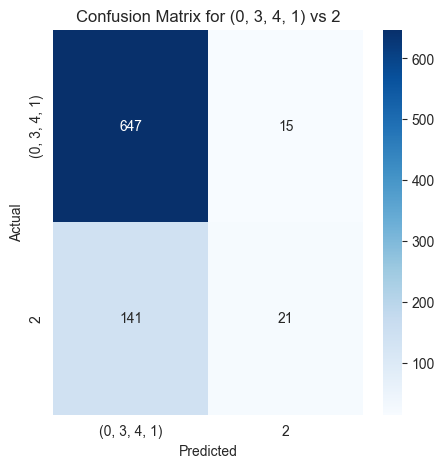

In [33]:
evaluate_model(model, val_generator, (0,3,4,1), 2)

In [34]:
# Get predicted labels
val_labels = val_generator.labels  # True labels
y_pred = (model.predict(val_generator).ravel() > 0.5).astype(int)  # Binary classification predictions

# Get image filenames from the generator
image_filenames = val_generator.filenames

# Separate correctly classified and misclassified images for label 2 (encoded as 1)
correctly_classified = []
misclassified = []

for filename, true_label, pred_label in zip(image_filenames, val_labels, y_pred):
    if true_label == 1:  # Only considering images of class 2 (encoded as 1)
        if pred_label == 1:
            correctly_classified.append([filename, "4"])  # Correctly classified as 2
        else:
            misclassified.append([filename, "(0,3)"])  # Misclassified as another class

# Create DataFrames
df_correct = pd.DataFrame(correctly_classified, columns=["ID Code", "Pred Label"])
df_misclassified = pd.DataFrame(misclassified, columns=["ID Code", "Missclassified Label"])

26/26 ━━━━━━━━━━━━━━━━━━━━ 15s 592ms/step


In [35]:
df_correct

,ID Code,Pred Label
0,5a03fe3ed15c.png,4
1,ee2c2a5f7d0e.png,4
2,daeaa5d8cf70_aug_210.png,4
3,92f313287a29.png,4
4,4189d4e631ec.png,4
5,63d217b059b6.png,4
6,1a369baf9ee6.png,4
7,ca891d37a43c.png,4
8,354b8911d6ed_aug_285.png,4
9,85cc6d636898.png,4


In [36]:
df_misclassified

,ID Code,Missclassified Label
0,73e83a07a16d.png,"(0,3)"
1,e599151ca14b_aug_400.png,"(0,3)"
2,e3a7671f787b.png,"(0,3)"
3,b2aaa81cc8f0.png,"(0,3)"
4,12025b34deb8_aug_253.png,"(0,3)"
...,...,...
136,d41b33fcb94f.png,"(0,3)"
137,465c618f7b23.png,"(0,3)"
138,46c1548d730e.png,"(0,3)"
139,876e1dd12d38_aug_115.png,"(0,3)"


In [37]:
# Path to your Excel file
excel_file_path = 'C:/Users/harma/OneDrive/Desktop/project2/data2/correctly_classified_label.xlsx'  # Replace with your file path

# Read the Excel file
try:
    # Load the Excel file into a DataFrame
    df = pd.read_excel(excel_file_path)

    # Display the DataFrame
    print("Excel sheet loaded successfully:")
    print(df)
except FileNotFoundError:
    print(f"Error: The file '{excel_file_path}' does not exist.")
except Exception as e:
    print(f"An error occurred while reading the Excel file: {e}")

Excel sheet loaded successfully:
              ID Code  Pred Label
0    f531232ecb55.png           0
1    58f07741ee3b.png           0
2    a73d012c4c38.png           0
3    1dfe599d12a9.png           0
4    2cfe8703f265.png           0
..                ...         ...
147  e4dcca36ceb4.png           0
148  d871895742b1.png           0
149  4c60f6fcea75.png           0
150  db52626d450c.png           0
151  763ad1236efe.png           0

[152 rows x 2 columns]


In [38]:
# Define the file path of the Excel file where you want to append data
file_path = 'C:/Users/harma/OneDrive/Desktop/project2/data2/correctly_classified_label.xlsx'

# Load the existing Excel file to work with it
with pd.ExcelWriter(file_path, engine='openpyxl', mode='a') as writer:
    # Append correctly classified labels for label 1
    df_correct = pd.DataFrame()  # Replace with actual DataFrame for label 1
    df_correct.to_excel(writer, sheet_name='Sheet1', startrow=writer.sheets['Sheet1'].max_row, header=False, index=False)

ValueError: Sheet 'Sheet1' already exists and if_sheet_exists is set to 'error'.

In [ ]:
# Save to separate Excel files
df_correct.to_excel("C:/Users/harma/OneDrive/Desktop/project2/data2/correctly_classified_label_4.xlsx", index=False)
df_misclassified.to_excel("C:/Users/harma/OneDrive/Desktop/project2/data2/misclassified_label_4.xlsx", index=False)